### Unit-Level Probability Time Series: LR M2, LGB M2, LSTM

Reproduces the professor's liked visualization for all three model families.
Each figure: 3 panels (Lignite / Gas / Hard Coal) for representative units.

**Prerequisites — run the last cell of `lightgbm_final.ipynb` first** to generate:
- `data/predictions/df_test.parquet`
- `data/predictions/cal_proba_lr2.npy`
- `data/predictions/cal_proba_lgb2.npy`

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

PRED_DIR      = '../data/predictions/'
MODELS_PATH   = '../models/'
FIGURES_PATH  = '../figures/'
FEATURES_PATH = '../data/features_v2.parquet'
TEST_YEARS    = [2023, 2024]
SEQ_LEN       = 48

# Representative units (confirmed in EDA: Lignite=97, Gas=53, HCoal=48 onsets)
UNITS = {
    'Lignite':    '11WD7NIED1B--H-9',
    'Gas':        '11WD2HUNT0000644',
    'Hard Coal':  '11WD2ZOL50001274',
}
FUEL_ORDER = ['Lignite', 'Gas', 'Hard Coal']

# LSTM sequence features (must match lstm_final.ipynb)
SEQUENCE_FEATURES = [
    'temperature_2m', 'relative_humidity_2m',
    'wind_speed_10m', 'precipitation', 'shortwave_radiation',
]

# Colour palette
C_CAL   = '#C44E52'   # calibrated / smoothed  — red
C_FILL  = '#f2b8ba'   # area fill              — pink
C_RAW   = '#4C72B0'   # raw hourly signal      — blue
C_ONSET = '#8B0000'   # onset marker           — dark red

print('Setup complete.')

Setup complete.


####  Load Test Metadata and LR/LGB Predictions

In [3]:
df_te = pd.read_parquet(PRED_DIR + 'df_test.parquet')
df_te['DateTime'] = pd.to_datetime(df_te['DateTime'])

p_lr2  = np.load(PRED_DIR + 'cal_proba_lr2.npy')
p_lgb2 = np.load(PRED_DIR + 'cal_proba_lgb2.npy')

assert len(df_te) == len(p_lr2) == len(p_lgb2),     f'Shape mismatch: {len(df_te)} vs {len(p_lr2)} vs {len(p_lgb2)}'

df_te['p_lr2']  = p_lr2
df_te['p_lgb2'] = p_lgb2

print(f'Test set: {len(df_te):,} rows')
print(f'\n{"Fuel":<12} {"Unit ID":<22} {"Rows":>8} {"Onsets":>8}')

for fuel, uid in UNITS.items():
    sub = df_te[df_te['EICCode'] == uid]
    print(f'{fuel:<12} {uid:<22} {len(sub):>8,} {int(sub["is_onset"].sum()):>8}')

Test set: 2,109,815 rows

Fuel         Unit ID                    Rows   Onsets
Lignite      11WD7NIED1B--H-9         16,463       97
Gas          11WD2HUNT0000644         16,482       53
Hard Coal    11WD2ZOL50001274         17,024       48


####  Load LSTM Model

In [4]:
class OutageLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True, dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 16), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(16, 1),
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :]).squeeze(-1)

ckpt      = torch.load(MODELS_PATH + 'lstm_model.pkl', map_location='cpu', weights_only=False)
lstm_net  = OutageLSTM()
lstm_net.load_state_dict(ckpt['state_dict'])
lstm_net.eval()

feat_mean = ckpt['feat_mean']   # shape (5,)
feat_std  = ckpt['feat_std']    # shape (5,)
print(f'LSTM loaded  |  feat_mean: {np.round(feat_mean, 2)}')
print(f'             |  feat_std:  {np.round(feat_std,  2)}')

LSTM loaded  |  feat_mean: [1.0840e+01 7.6330e+01 3.4400e+00 8.0000e-02 1.2959e+02]
             |  feat_std:  [  7.7   16.31   1.83   0.31 201.22]


####  Per-Unit LSTM Inference

In [5]:
def infer_unit_lstm(unit_df, seq_len=SEQ_LEN, batch_size=512):
    """Vectorized sequence construction + batched forward pass for one unit."""
    feats  = unit_df[SEQUENCE_FEATURES].fillna(0).values.astype(np.float32)  # (T, 5)
    n      = len(feats)
    padded = np.concatenate(
        [np.zeros((seq_len - 1, feats.shape[1]), dtype=np.float32), feats], axis=0
    )
    # For row i: window = padded[i : i+seq_len]  (ends at feats[i])
    idx       = np.arange(n)[:, None] + np.arange(seq_len)[None, :]  # (n, seq_len)
    sequences = (padded[idx] - feat_mean) / feat_std                 # (n, seq_len, 5)
    probs = []
    with torch.no_grad():
        for start in range(0, n, batch_size):
            xb = torch.from_numpy(sequences[start : start + batch_size])
            probs.append(torch.sigmoid(lstm_net(xb)).numpy())
    return np.concatenate(probs)

# Load sequence features for the 3 units (test years only)
print('Loading LSTM feature columns for 3 units...')
df_seq = pd.read_parquet(
    FEATURES_PATH,
    columns=['DateTime', 'EICCode', 'is_onset', 'year'] + SEQUENCE_FEATURES,
)
df_seq = df_seq[
    (df_seq['year'].isin(TEST_YEARS)) &
    (df_seq['EICCode'].isin(list(UNITS.values())))
].copy()
df_seq['DateTime'] = pd.to_datetime(df_seq['DateTime'])
df_seq = df_seq.sort_values(['EICCode', 'DateTime']).reset_index(drop=True)

lstm_preds = {}
for fuel, uid in UNITS.items():
    unit_df = df_seq[df_seq['EICCode'] == uid].reset_index(drop=True)
    print(f'  {fuel} ({uid}): {len(unit_df):,} rows ... ', end='', flush=True)
    lstm_preds[uid] = infer_unit_lstm(unit_df)
    lo, hi = lstm_preds[uid].min(), lstm_preds[uid].max()
    print(f'done  range=[{lo:.3f}, {hi:.3f}]')

Loading LSTM feature columns for 3 units...
  Lignite (11WD7NIED1B--H-9): 16,463 rows ... done  range=[0.420, 0.850]
  Gas (11WD2HUNT0000644): 16,482 rows ... done  range=[0.428, 0.843]
  Hard Coal (11WD2ZOL50001274): 17,024 rows ... done  range=[0.426, 0.833]


####  Helper Functions

In [6]:
def forward_5d_prob(p_hourly, window=120):
    """P_5d(t) = 1 − prod_{i=t}^{t+window-1}(1 − p_i).

    Computed via log-sum reversal trick: reverse array, rolling backward sum,
    reverse back. At the tail (< window future steps) min_periods=1 uses
    available steps.
    """
    p     = np.clip(p_hourly, 1e-9, 1 - 1e-9)
    log_s = np.log1p(-p)
    rev   = pd.Series(log_s[::-1]).rolling(window, min_periods=1).sum().values
    return np.clip(1 - np.exp(rev[::-1]), 0, 1)


def _add_onset_markers(ax, dt_arr, onset_mask):
    for dt in pd.to_datetime(dt_arr)[onset_mask]:
        ax.axvline(dt, color=C_ONSET, lw=0.8, alpha=0.65, zorder=5)


def _format_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8.5)


def draw_unit_panel(ax, dt_pd, p_smooth, p_raw, onset_mask,
                    ylabel, title, show_legend=False):
    """Draw one panel: pink fill + red smooth line + blue raw line + onset markers."""
    ax.fill_between(dt_pd, 0, p_smooth, color=C_FILL, alpha=0.55, zorder=2)
    ax.plot(dt_pd, p_smooth, color=C_CAL, lw=1.6, zorder=3)
    ax.plot(dt_pd, p_raw,    color=C_RAW, lw=0.6, alpha=0.40, zorder=2)
    _add_onset_markers(ax, dt_pd, onset_mask)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(dt_pd.min(), dt_pd.max())
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.15)
    ax.spines[['top', 'right']].set_visible(False)
    _format_xaxis(ax)

    if show_legend:
        handles = [
            matplotlib.lines.Line2D([0], [0], color=C_CAL, lw=2.0,
                                    label='5-day forward probability'),
            matplotlib.lines.Line2D([0], [0], color=C_RAW, lw=1.2, alpha=0.6,
                                    label='Hourly probability'),
            mpatches.Patch(facecolor=C_ONSET, alpha=0.7,
                           label=f'Onset events ({onset_mask.sum()})'),
        ]
        ax.legend(handles=handles, fontsize=8, loc='upper right',
                  framealpha=0.92, edgecolor='#cccccc')

print('Helper functions defined.')

Helper functions defined.


####  Figure 1 — LR M2

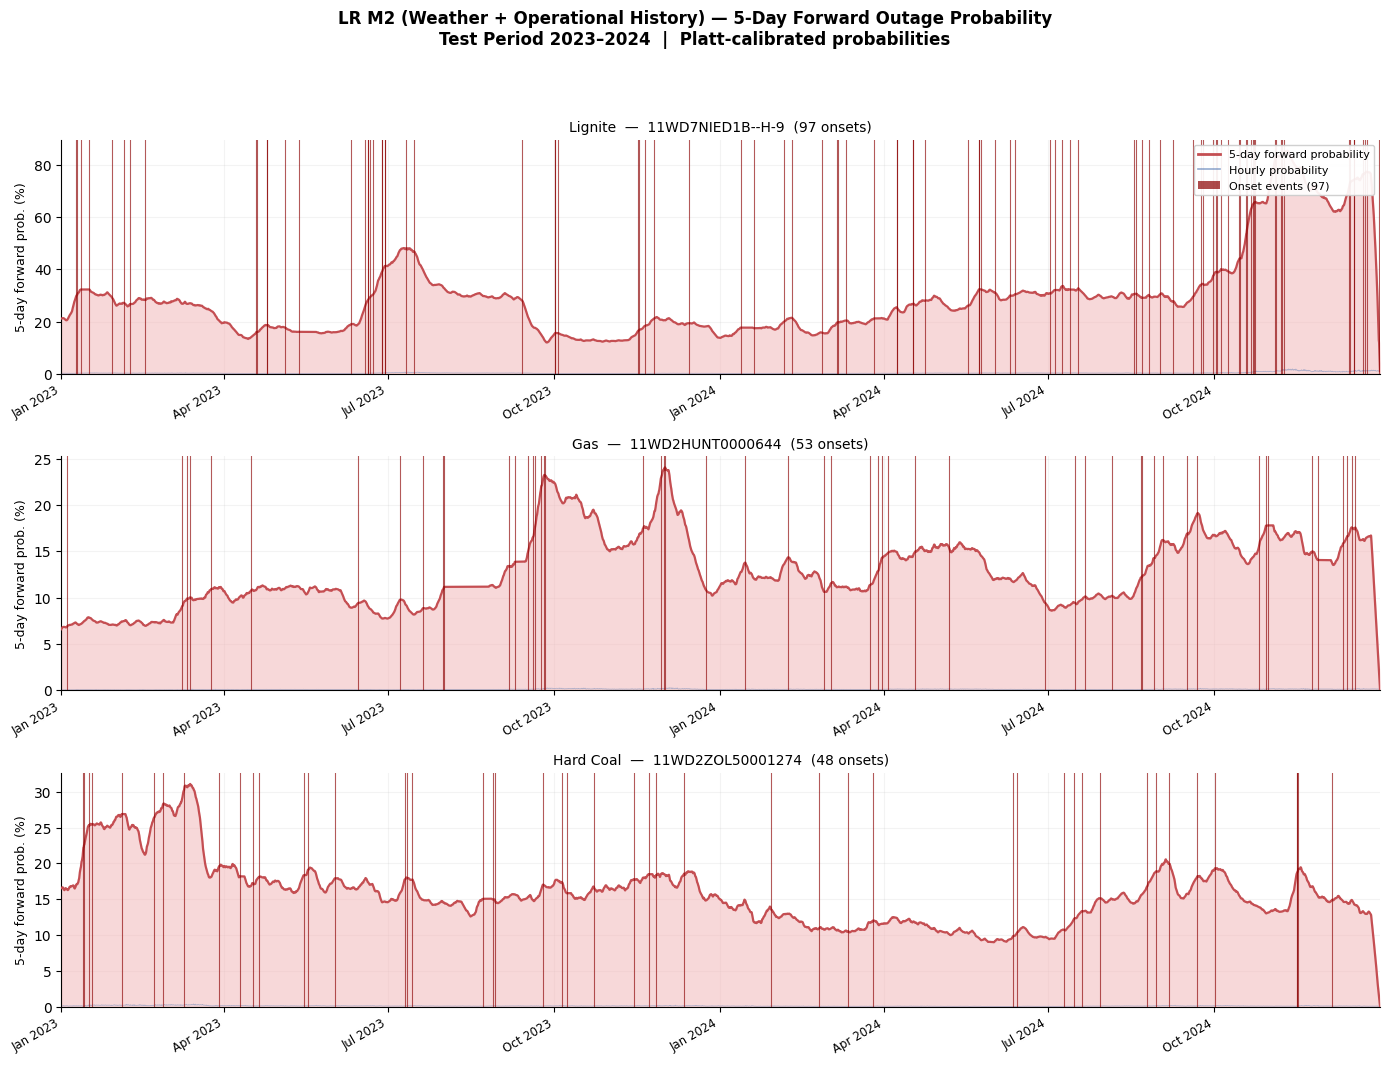

Saved: pred_plot_lr_m2.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10.5))
fig.suptitle(
    'LR M2 (Weather + Operational History) — 5-Day Forward Outage Probability\n'
    'Test Period 2023–2024  |  Platt-calibrated probabilities',
    fontsize=12, fontweight='semibold', y=1.01,
)

for i, (ax, fuel) in enumerate(zip(axes, FUEL_ORDER)):
    uid      = UNITS[fuel]
    unit_df  = df_te[df_te['EICCode'] == uid].sort_values('DateTime')
    dt_pd    = pd.to_datetime(unit_df['DateTime'].values)
    p_raw    = unit_df['p_lr2'].values
    p_smooth = forward_5d_prob(p_raw) * 100   # percent
    onset_mask = unit_df['is_onset'].values.astype(bool)
    n_onsets   = int(onset_mask.sum())

    draw_unit_panel(
        ax, dt_pd,
        p_smooth  = p_smooth,
        p_raw     = p_raw * 100,
        onset_mask= onset_mask,
        ylabel    = '5-day forward prob. (%)',
        title     = f'{fuel}  —  {uid}  ({n_onsets} onsets)',
        show_legend = (i == 0),
    )

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIGURES_PATH + 'pred_plot_lr_m2.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: pred_plot_lr_m2.png')

####  Figure 2 — LGB M2

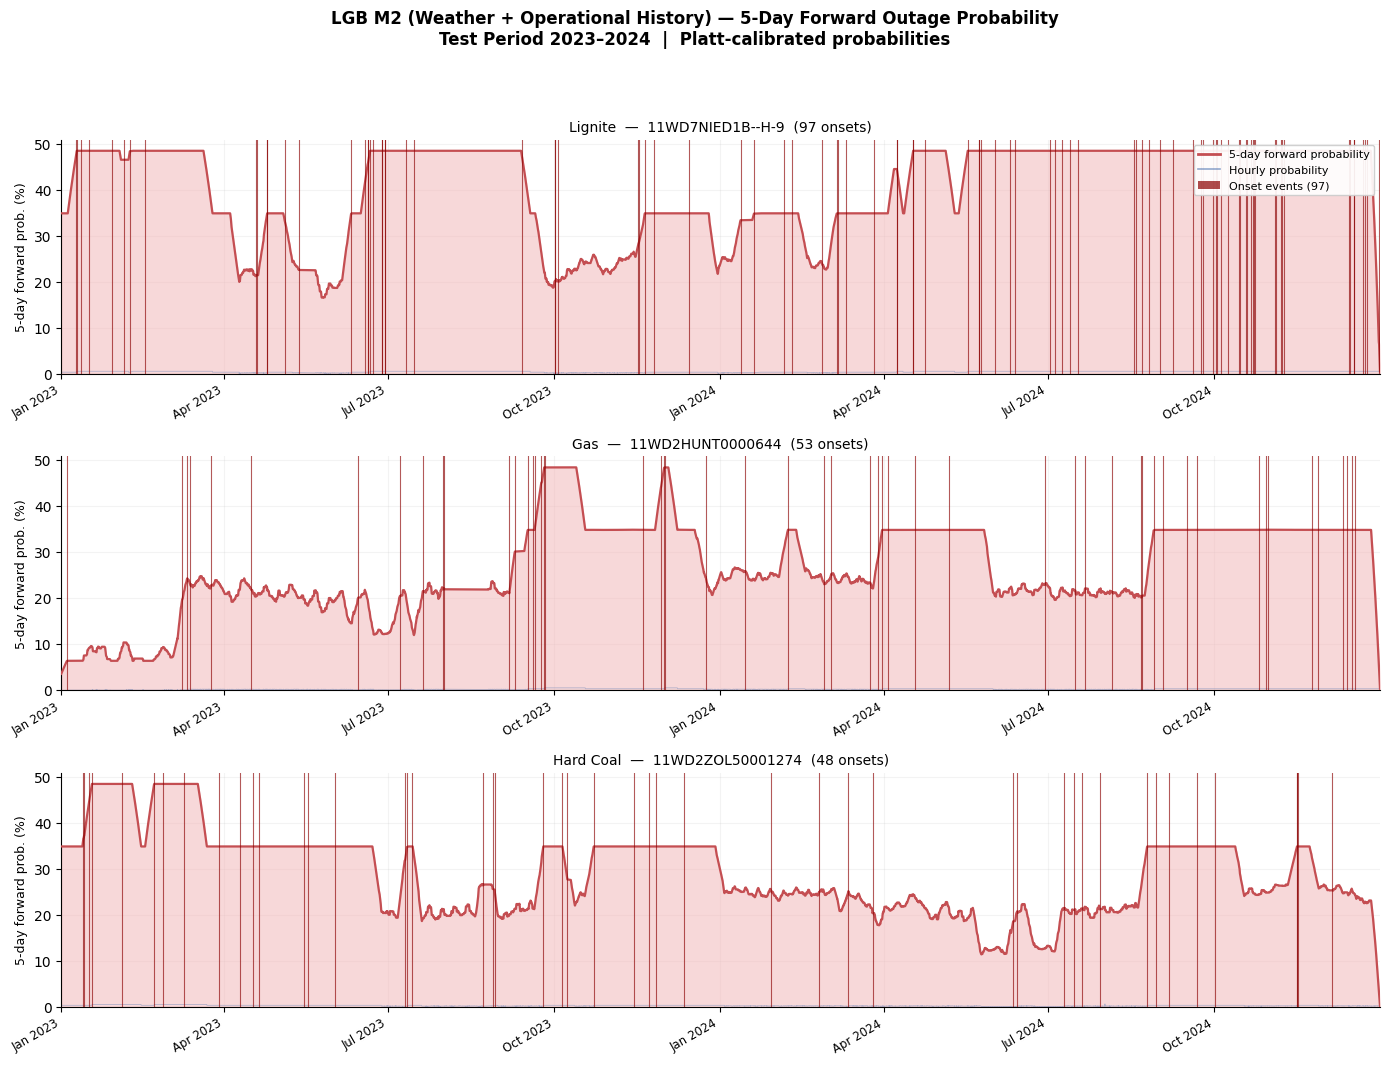

Saved: pred_plot_lgb_m2.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10.5))
fig.suptitle(
    'LGB M2 (Weather + Operational History) — 5-Day Forward Outage Probability\n'
    'Test Period 2023–2024  |  Platt-calibrated probabilities',
    fontsize=12, fontweight='semibold', y=1.01,
)

for i, (ax, fuel) in enumerate(zip(axes, FUEL_ORDER)):
    uid      = UNITS[fuel]
    unit_df  = df_te[df_te['EICCode'] == uid].sort_values('DateTime')
    dt_pd    = pd.to_datetime(unit_df['DateTime'].values)
    p_raw    = unit_df['p_lgb2'].values
    p_smooth = forward_5d_prob(p_raw) * 100
    onset_mask = unit_df['is_onset'].values.astype(bool)
    n_onsets   = int(onset_mask.sum())

    draw_unit_panel(
        ax, dt_pd,
        p_smooth  = p_smooth,
        p_raw     = p_raw * 100,
        onset_mask= onset_mask,
        ylabel    = '5-day forward prob. (%)',
        title     = f'{fuel}  —  {uid}  ({n_onsets} onsets)',
        show_legend = (i == 0),
    )

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIGURES_PATH + 'pred_plot_lgb_m2.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: pred_plot_lgb_m2.png')

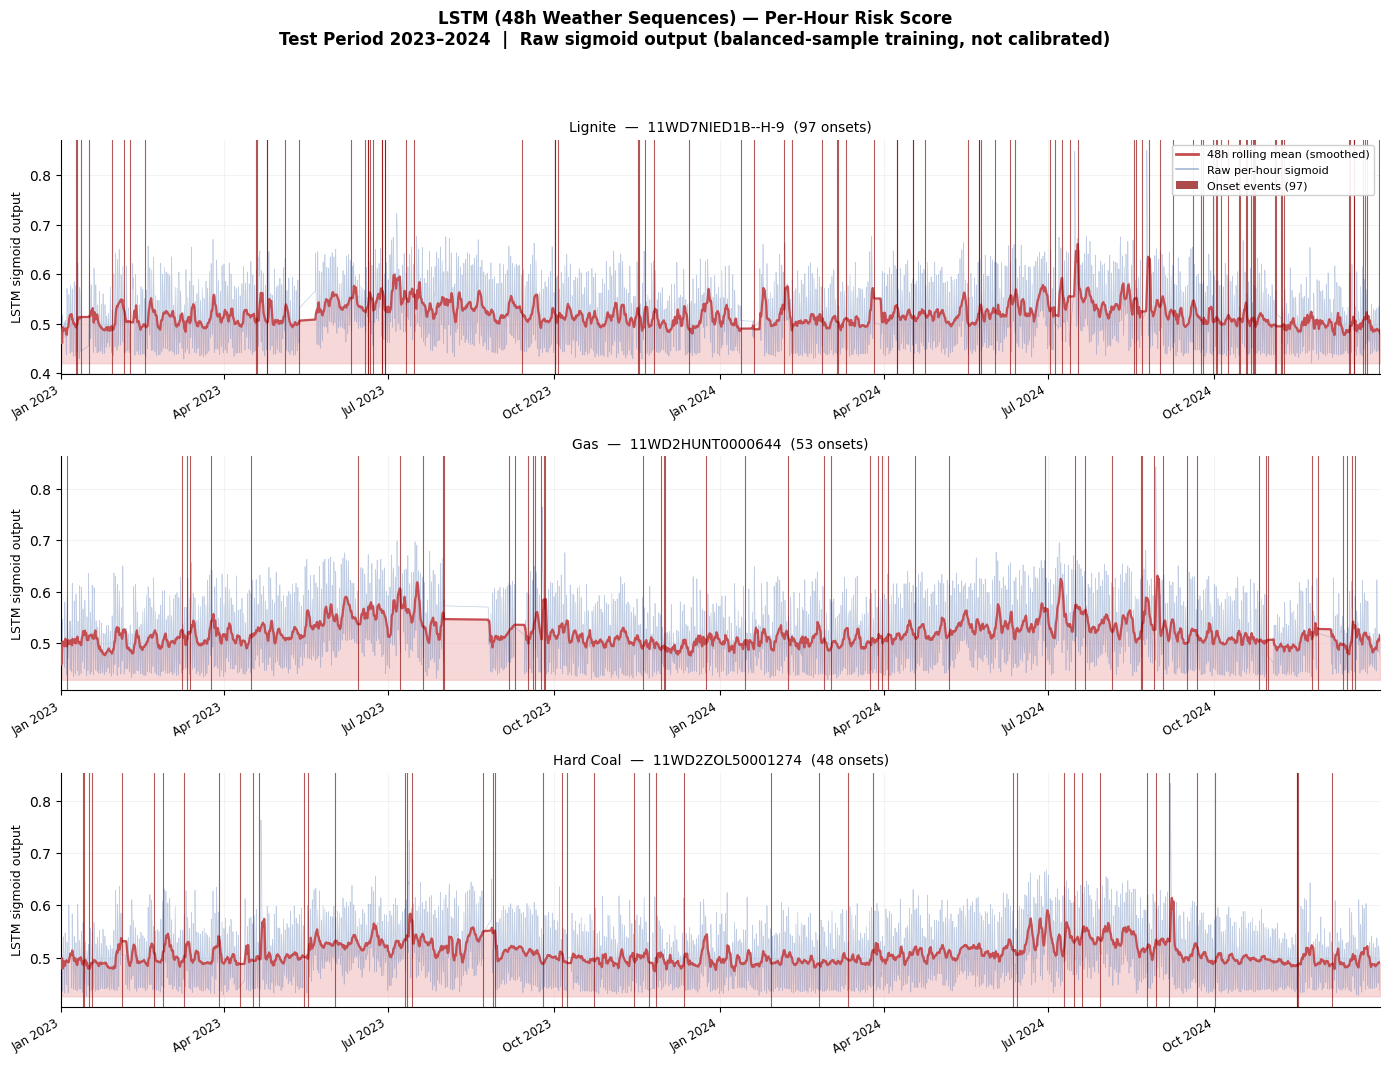

Saved: pred_plot_lstm.png


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10.5))
fig.suptitle(
    'LSTM (48h Weather Sequences) — Per-Hour Risk Score\n'
    'Test Period 2023–2024  |  Raw sigmoid output (balanced-sample training, not calibrated)',
    fontsize=12, fontweight='semibold', y=1.01,
)

SMOOTH_W = 48  # 48-hour rolling mean replaces 5-day forward (sigmoid ≈ 0.6 → P_5d ≈ 1)

for i, (ax, fuel) in enumerate(zip(axes, FUEL_ORDER)):
    uid        = UNITS[fuel]
    unit_seq   = df_seq[df_seq['EICCode'] == uid].sort_values('DateTime')
    dt_pd      = pd.to_datetime(unit_seq['DateTime'].values)
    p_raw      = lstm_preds[uid]
    p_smooth   = pd.Series(p_raw).rolling(SMOOTH_W, min_periods=1).mean().values
    onset_mask = unit_seq['is_onset'].values.astype(bool)
    n_onsets   = int(onset_mask.sum())

    ax.fill_between(dt_pd, p_raw.min(), p_smooth, color=C_FILL, alpha=0.55, zorder=2)
    ax.plot(dt_pd, p_smooth, color=C_CAL, lw=1.6, zorder=3)
    ax.plot(dt_pd, p_raw,    color=C_RAW, lw=0.5, alpha=0.35, zorder=2)
    _add_onset_markers(ax, dt_pd, onset_mask)

    ax.set_ylabel('LSTM sigmoid output', fontsize=9)
    ax.set_title(f'{fuel}  —  {uid}  ({n_onsets} onsets)', fontsize=10)
    ax.set_xlim(dt_pd.min(), dt_pd.max())
    ax.grid(alpha=0.15)
    ax.spines[['top', 'right']].set_visible(False)
    _format_xaxis(ax)

    if i == 0:
        handles = [
            matplotlib.lines.Line2D([0], [0], color=C_CAL, lw=2.0,
                                    label=f'48h rolling mean (smoothed)'),
            matplotlib.lines.Line2D([0], [0], color=C_RAW, lw=1.2, alpha=0.5,
                                    label='Raw per-hour sigmoid'),
            mpatches.Patch(facecolor=C_ONSET, alpha=0.7,
                           label=f'Onset events ({n_onsets})'),
        ]
        ax.legend(handles=handles, fontsize=8, loc='upper right',
                  framealpha=0.92, edgecolor='#cccccc')

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIGURES_PATH + 'pred_plot_lstm.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: pred_plot_lstm.png')